In [7]:
using ForwardDiff
using Plots
using Printf

In [8]:
"""
    pt([x::Real, y::Real]) -> Real
    
    Determine the utility of the point [x,y].
"""
function p(x::Vector{T}) where T<:Real
    metric1 = 60.0 / ( 1.0+ (x[1] + 1.0)^2 + ( x[2] - 3.0)^2)
    metric2 = 20.0 / ( 1.0 + (x[1] - 1.0)^2 + ( x[2] - 3.0)^2)
    metric3 = 30.0 / ( 1.0 + (x[1])^2 + ( x[2] + 4.0)^2)
    return metric1 + metric2 + metric3
end

p

In [9]:

"""
    isFeasible([x::Real, y::Real]) -> Bool
    
    Check if the point [x,y] is feasible based on the given constraints.
"""
function isFeasible(x::Vector{T}) where T<:Real
    test1 = (x[1] + 1.0)^2 + (x[2] - 3.0)^2 >= 0.25
    test2 = (x[1] - 1.0)^2 + (x[2] - 3.0)^2 >= 0.25
    test3 = (x[1])^2 + (x[2] + 4.0)^2 >= 0.25
    return test1 && test2 && test3
end

isFeasible

In [10]:

"""
    move([x::Real, y::Real], λ::Real) -> Vector{Real}
    
    Move the point [x,y] in the direction of the gradient of the utility function p by a step size λ.
"""
function move(pt::Vector{T}, λ::T) where T<:Real
    grad = ForwardDiff.gradient(p, pt)
    return pt + λ * grad
end

move

In [11]:
"""
    search([x::Real, y::Real], λ::Real) -> Tuple{Vector{Real}, Vector{Real}, Real}
    
    Perform a search starting from the point [x,y] with step size λ, 
    returning vectors of the x and y coordinates of the path 
    and the final utility value.
"""
function search(start_pt::Vector{T}, λ::T) where T<:Real
    path_x = Vector{T}() 
    path_y = Vector{T}() 

    pt = start_pt
    metric = p(pt)
    prior_metric = -100.00

    
    while isFeasible(pt) && (metric > prior_metric)
        push!(path_x, pt[1])
        push!(path_y, pt[2])
        prior_metric = metric
        pt = move(pt, λ)
        metric = p(pt)
    end

    return path_x, path_y, prior_metric
end


search

Search Paths

Path for y=-2.0:  End Pt: (-0.00, -3.50) Metric= 25.78
Path for y=-1.5:  End Pt: (-0.01, -3.50) Metric= 25.80
Path for y=-1.0:  End Pt: (-0.76, 2.56) Metric= 53.20
Path for y=-0.5:  End Pt: (-0.74, 2.57) Metric= 53.40
Path for y=0.0:  End Pt: (-0.72, 2.58) Metric= 53.44
Path for y=0.5:  End Pt: (-0.70, 2.60) Metric= 53.58
Path for y=1.0:  End Pt: (-0.67, 2.62) Metric= 53.67
Path for y=1.5:  End Pt: (-0.63, 2.66) Metric= 53.88
Path for y=2.0:  End Pt: (-0.58, 2.72) Metric= 54.12
Path for y=2.5:  End Pt: (-0.53, 2.83) Metric= 54.52
Path for y=3.0:  End Pt: (-0.50, 3.00) Metric= 54.65
Path for y=3.5:  End Pt: (-0.53, 3.17) Metric= 54.46
Path for y=4.0:  End Pt: (-0.58, 3.28) Metric= 54.13


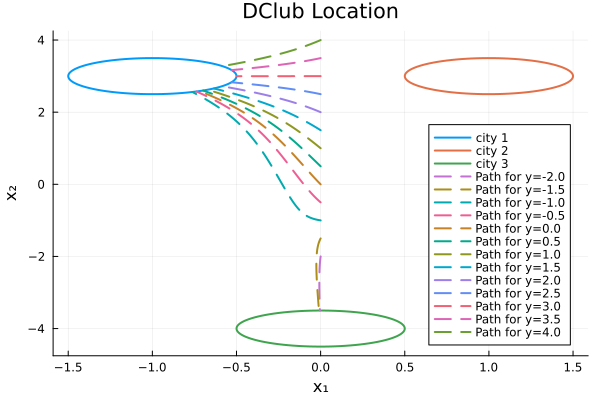

In [12]:
# Function to generate parametric coordinates for a circle centered at (h, k)
circle_pts(h, k, r=0.5; n=100) = (
    h .+ r .* cos.(range(0, 2π, length=n)),
    k .+ r .* sin.(range(0, 2π, length=n))
)

# Compute coordinates for each circle
c1_x, c1_y = circle_pts(-1.0, 3.0)   # test1 center: (-1.0, 3.0)
c2_x, c2_y = circle_pts(1.0, 3.0)    # test2 center: (1.0, 3.0)
c3_x, c3_y = circle_pts(0.0, -4.0)   # test3 center: (0.0, -4.0)

# Plot circles
plt = plot()
plot!(plt, c1_x, c1_y, label="city 1", lw=2)
plot!(plt, c2_x, c2_y, label="city 2", lw=2)
plot!(plt, c3_x, c3_y, label="city 3", lw=2, xlabel="x₁", ylabel="x₂", title="DClub Location")

λ = 0.0001

metrics = []
x = 0.0

println("Search Paths\n")
for y in -2.0:0.5:4.0
    path_x, path_y, metric = search([x, y], λ)
    end_x = @sprintf("%.2f", path_x[end])
    end_y = @sprintf("%.2f", path_y[end])
    metric = @sprintf("%.2f", metric)
    println("Path for y=$y:  End Pt: ($end_x, $end_y) Metric= $metric")
    plot!(plt, path_x, path_y, label="Path for y=$y", lw=2, linestyle=:dash)
    push!(metrics, metric)
end

display(plt)